# Feature Engineering Notebook

## Feature Descriptions

### Power & Energy Features
- **power_kw**: Mechanical power in kilowatts, calculated from torque and rotational speed using the formula: P = T × ω
- **log_power**: Natural logarithm of power_kw for capturing non-linear relationships and reducing skewness

### Temperature Features
- **temp_delta**: Temperature difference between process and ambient air in Kelvin, indicating thermal operating conditions

### Torque & Mechanical Features
- **strain_index**: Normalized torque relative to rotational speed, representing mechanical stress per unit speed
- **tool_wear_torque**: Product of tool wear and torque, capturing the compounding effect of wear on tool stress

### Combined Features
- **power_x_wear**: Interaction feature between power consumption and tool wear, capturing combined degradation effects
- **type_ordinal**: Ordinal encoding of machine type (L=0, M=1, H=2) for categorical representation

### Risk Indicators
- **hdl_risk**: Binary flag indicating high risk of failure based on domain knowledge thresholds:
  - Temperature delta < 8.6K AND Rotational speed < 1380 RPM

### Lag Features (Time-Series)
- **power_lag[5, 10, 20]**: Previous power values at 5, 10, and 20 steps back, capturing historical patterns
- **power_delta[5, 10, 20]**: Change in power consumption over 5, 10, and 20 step intervals, measuring power trends

### Rolling Window Features (Volatility)
- **torque_roll[5, 20]_std**: Standard deviation of torque over rolling windows of 5 and 20 steps, measuring mechanical variability and instability



In [4]:
# Code for feature engineering goes here
import pandas as pd
import numpy as np

df = pd.read_csv('../data/predictive_maintenance.csv')
# --- Stateless: safe to compute before split ---
df['power_kw']         = df['Torque [Nm]'] * (df['Rotational speed [rpm]'] * 2 * np.pi / 60)
df['temp_delta']        = df['Process temperature [K]'] - df['Air temperature [K]']
df['strain_index']      = df['Torque [Nm]'] / (df['Rotational speed [rpm]'] + 1e-6)
df['tool_wear_torque']  = df['Tool wear [min]'] * df['Torque [Nm]']
df['power_x_wear']      = df['power_kw'] * df['Tool wear [min]']
df['log_power']         = np.log1p(df['power_kw'])
df['type_ordinal']      = df['Type'].map({'L': 0, 'M': 1, 'H': 2})

# Physics-based flags — thresholds from domain knowledge, not data
df['hdl_risk'] = ((df['temp_delta'] < 8.6) & (df['Rotational speed [rpm]'] < 1380)).astype(int)

# Lag features — backward-looking only, safe before split
# CRITICAL: shift(1) before rolling so current row isn't in its own window
for lag in [5, 10, 20]:
    df[f'power_lag{lag}']   = df['power_kw'].shift(lag)
    df[f'power_delta{lag}'] = df['power_kw'] - df['power_kw'].shift(lag)

for window in [5, 20]:
    df[f'torque_roll{window}_std'] = (
        df['Torque [Nm]'].shift(1).rolling(window, min_periods=2).std()
    )

# Drop NaN rows produced by lag/rolling (first 100 rows)
df = df.dropna().reset_index(drop=True)
df.head()


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Failure Type,...,type_ordinal,hdl_risk,power_lag5,power_delta5,power_lag10,power_delta10,power_lag20,power_delta20,torque_roll5_std,torque_roll20_std
0,21,H29434,H,298.9,309.3,1375,42.7,58,0,No Failure,...,2,0,7815.528540,-1667.169917,4459.993427,1688.365196,6951.590560,-803.231938,8.056488,9.590544
1,22,L47201,L,298.8,309.3,1450,44.8,63,0,No Failure,...,0,0,6397.602112,404.993181,6601.418171,201.177122,6826.722724,-24.127432,7.949654,9.588912
2,23,M14882,M,298.9,309.3,1581,30.7,65,0,No Failure,...,1,0,6733.061375,-1650.310037,7165.229333,-2082.477994,7749.387543,-2666.636204,7.864286,9.540937
3,24,L47203,L,299.0,309.4,1758,25.7,68,0,No Failure,...,0,0,7453.638010,-2722.336642,5472.654403,-741.353034,5927.504659,-1196.203291,9.719979,9.456230
4,25,M14884,M,299.0,309.4,1561,37.3,70,0,No Failure,...,1,0,5554.335812,543.003346,4176.852153,1920.487005,5897.816608,199.522549,8.157328,9.893160


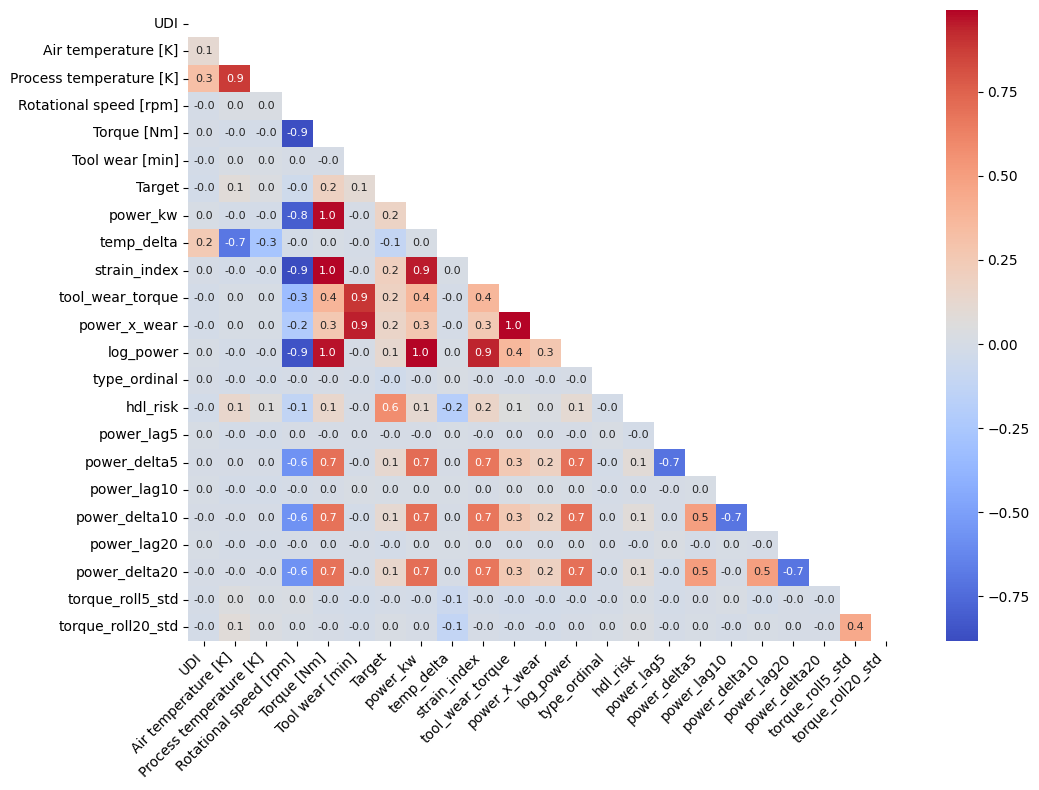

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Compute correlation (numeric columns only)
corr = df.select_dtypes(include='number').corr()

# Create mask for upper triangle
mask = np.triu(np.ones_like(corr, dtype=bool))

# Plot heatmap
plt.figure(figsize=(11, 8))

sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt=".1f",                 # fewer decimals → more readable
    cmap='coolwarm',
    annot_kws={"size": 8}      # smaller text
)

plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()